In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", iris.target_names)

Dataset loaded successfully!
Number of samples: 150
Number of features: 4
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["Species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


In [7]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


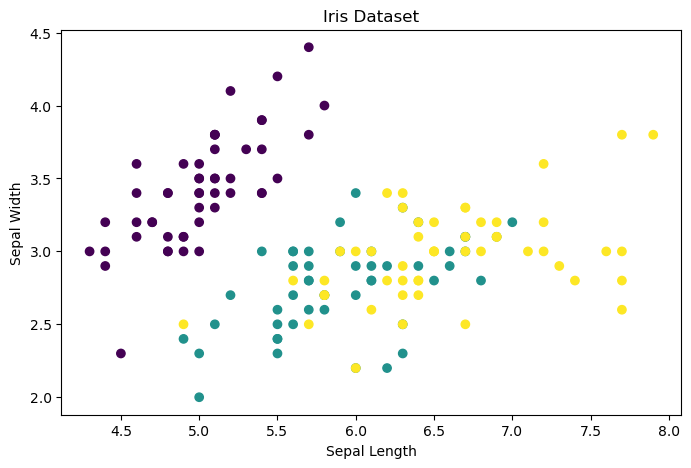

In [8]:
#data visualization
## Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y
)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset")
plt.show()

In [9]:
## Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [10]:
## Standardize Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [11]:
## Create Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "SVM": SVC(
        kernel="rbf",
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(),
    
    "Naive Bayes": GaussianNB()
}

In [12]:
##Train All Models
results = []

predictions = {}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    predictions[name] = y_pred
    
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(
        y_test,
        y_pred,
        average="macro"
    )
    
    recall = recall_score(
        y_test,
        y_pred,
        average="macro"
    )
    
    results.append([
        name,
        precision,
        recall,
        accuracy
    ])

In [13]:
#Comparison Table
## Display results
results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Precision",
        "Recall",
        "Accuracy"
    ]
)

results_df

,Algorithm,Precision,Recall,Accuracy
0,Logistic Regression,0.933333,0.933333,0.933333
1,Decision Tree,0.933333,0.933333,0.933333
2,Random Forest,0.902357,0.900000,0.900000
3,SVM,0.969697,0.966667,0.966667
4,KNN,0.944444,0.933333,0.933333
5,Naive Bayes,0.969697,0.966667,0.966667


In [14]:
##Round the Results
results_df[
    ["Precision", "Recall", "Accuracy"]
] = results_df[
    ["Precision", "Recall", "Accuracy"]
].round(3)

results_df

,Algorithm,Precision,Recall,Accuracy
0,Logistic Regression,0.933,0.933,0.933
1,Decision Tree,0.933,0.933,0.933
2,Random Forest,0.902,0.900,0.900
3,SVM,0.970,0.967,0.967
4,KNN,0.944,0.933,0.933
5,Naive Bayes,0.970,0.967,0.967


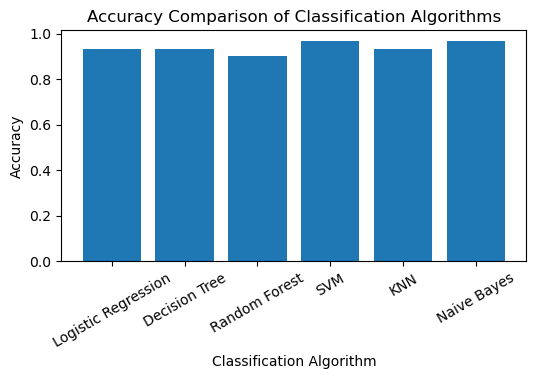

In [15]:
#Accuracy comparison
plt.figure(figsize=(6,3))

plt.bar(
    results_df["Algorithm"],
    results_df["Accuracy"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Algorithms")

plt.xticks(rotation=30)

plt.show()

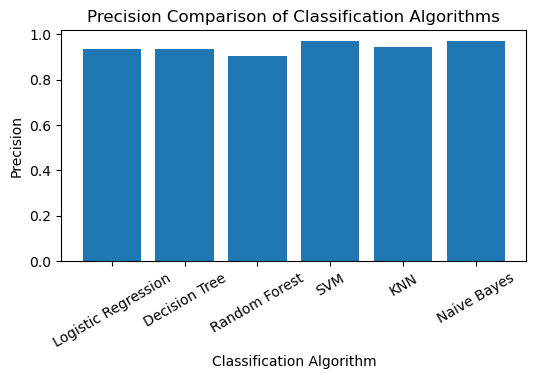

In [16]:
#Precision Comparison
plt.figure(figsize=(6,3))

plt.bar(
    results_df["Algorithm"],
    results_df["Precision"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Precision")
plt.title("Precision Comparison of Classification Algorithms")

plt.xticks(rotation=30)

plt.show()

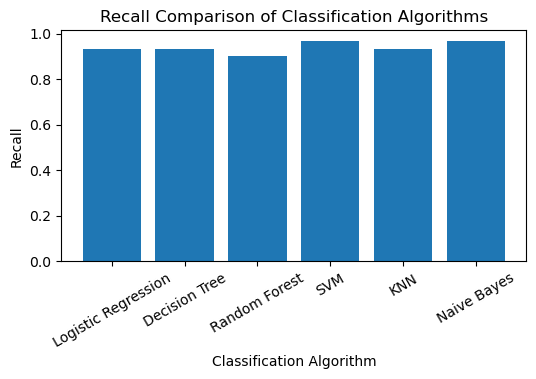

In [17]:
#Recall Comparison
plt.figure(figsize=(6,3))

plt.bar(
    results_df["Algorithm"],
    results_df["Recall"]
)

plt.xlabel("Classification Algorithm")
plt.ylabel("Recall")
plt.title("Recall Comparison of Classification Algorithms")

plt.xticks(rotation=30)

plt.show()

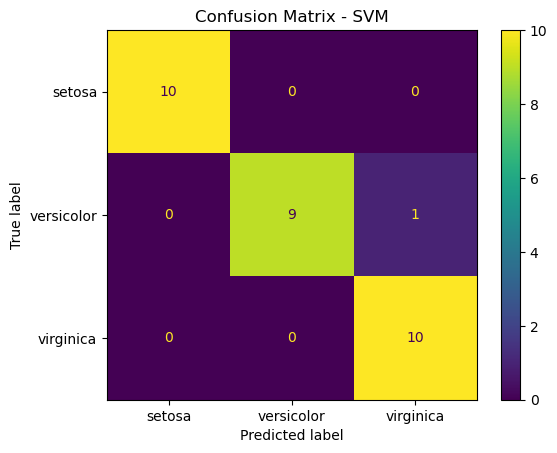

In [18]:
#Confusion Matrix
## SVM Confusion Matrix
svm_predictions = predictions["SVM"]

cm = confusion_matrix(
    y_test,
    svm_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Confusion Matrix - SVM")
plt.show()

In [19]:
#Find the best model
best_accuracy_model = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Algorithm"
]

best_precision_model = results_df.loc[
    results_df["Precision"].idxmax(),
    "Algorithm"
]

best_recall_model = results_df.loc[
    results_df["Recall"].idxmax(),
    "Algorithm"
]

print("Highest Accuracy :", best_accuracy_model)
print("Highest Precision:", best_precision_model)
print("Highest Recall   :", best_recall_model)

Highest Accuracy : SVM
Highest Precision: SVM
Highest Recall   : SVM
